# AI & Machine Learning – Task 2

## Feature Engineering, Model Optimization & Performance Comparison

**Name:** Ravada Rupalatha

**Objective:** Compare multiple regression models using the California Housing Dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load the California Housing Dataset
housing = fetch_california_housing()

# Create a DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add target column
df["Price"] = housing.target

# Display first 5 rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Dataset Shape
print("Shape:", df.shape)

# Dataset Information
print("\nDataset Information:")
df.info()

# Statistical Summary
print("\nStatistical Summary:")
display(df.describe())

# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (20640, 9)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Statistical Summary:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010



Missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64


In [4]:
# Separate Features and Target
X = df.drop("Price", axis=1)
y = df["Price"]

# Feature Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed!")

Feature Scaling Completed!


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (16512, 8)
Testing Data: (4128, 8)


In [6]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

In [7]:
ridge_model = Ridge()

ridge_model.fit(X_train, y_train)

ridge_predictions = ridge_model.predict(X_test)

In [8]:
tree_model = DecisionTreeRegressor(random_state=42)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

In [9]:
def evaluate_model(name, actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)
    return [name, rmse, r2]

results = [
    evaluate_model("Linear Regression", y_test, linear_predictions),
    evaluate_model("Ridge Regression", y_test, ridge_predictions),
    evaluate_model("Decision Tree", y_test, tree_predictions)
]

results_df = pd.DataFrame(
    results,
    columns=["Model", "RMSE", "R² Score"]
)

results_df

,Model,RMSE,R² Score
0,Linear Regression,0.745581,0.575788
1,Ridge Regression,0.745554,0.575819
2,Decision Tree,0.702173,0.623746


In [10]:
best_model = results_df.sort_values(
    by="R² Score",
    ascending=False
)

best_model

,Model,RMSE,R² Score
2,Decision Tree,0.702173,0.623746
1,Ridge Regression,0.745554,0.575819
0,Linear Regression,0.745581,0.575788


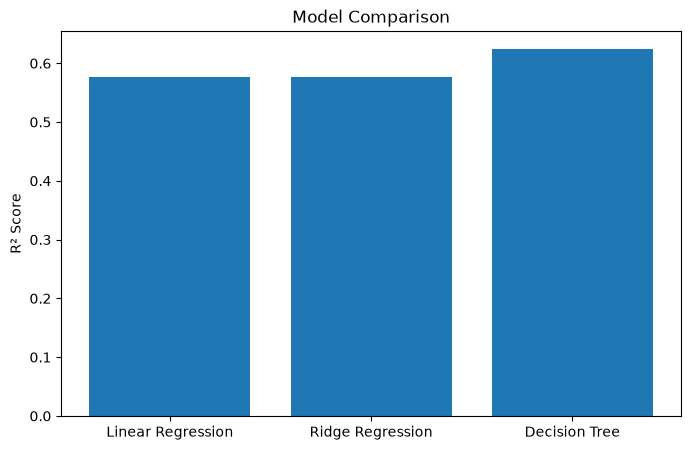

In [11]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["R² Score"])

plt.title("Model Comparison")

plt.ylabel("R² Score")

plt.show()

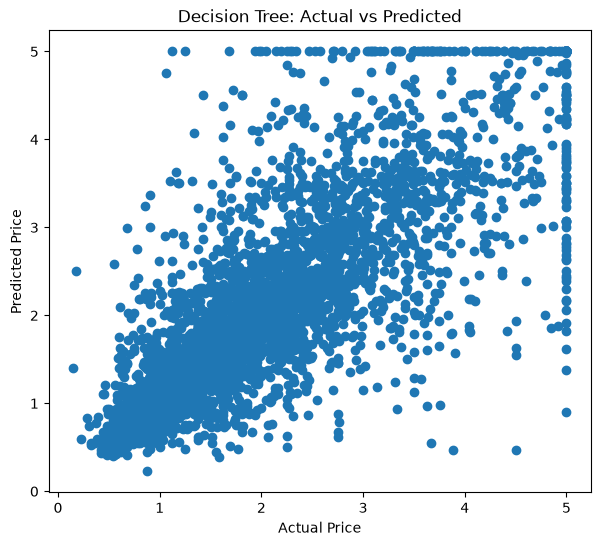

In [12]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, tree_predictions)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Decision Tree: Actual vs Predicted")

plt.show()

# Conclusion

Three regression models were trained and compared using the California Housing Dataset.

Feature scaling was applied before training.

Based on the evaluation metrics, the best-performing model was identified using RMSE and R² Score.

The comparison helped understand how different regression algorithms perform on the same dataset.